### **Libraries Import**
This cell imports necessary libraries for data manipulation, numerical operations, plotting, and visualization.

# first we want to import the libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### **Upload Dataset**
This cell prompts the user to upload a CSV file, which will be used as the dataset for analysis. If two csv files are uploaded, then the first one will be used.

# next we should upload a dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Q01_solar_farm.csv to Q01_solar_farm (1).csv


### **Upload Dataset (Duplicate)**
This cell also prompts the user to upload a CSV file. It appears there was a duplicate upload attempt. The analysis will proceed with the first uploaded file.

# we have import all files and load the dataset from the solar.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Q01_solar_farm.csv to Q01_solar_farm (2).csv


### **Load Dataset from `/content` Directory**
This cell loads the CSV file from the `/content` directory, automatically identifying the first CSV file found. It then prints the file path, number of rows, and columns, and displays the first 5 rows of the DataFrame.

# load the dataset and check it loades and check the row and columns

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Q01_solar_farm (1).csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 123
Columns: 7


,record_id,timestamp,farm,panel_capacity_kw,panel_output_kwh,ambient_temperature_c,sunlight_duration_hours
0,SOL0001,2026-03-27 03:39,Farm_D,150,128.04,22.0,9.5
1,SOL0002,2026-04-25 07:13,Farm_B,100,50.47,32.3,5.0
2,SOL0003,2026-06-03 16:42,Farm_A,120,52.05,30.4,4.3
3,SOL0004,2026-03-20 21:39,Farm_B,120,54.61,29.4,4.5
4,SOL0005,2026-07-20 15:54,Farm_D,100,79.42,29.8,8.3


### **Load Dataset and Initial Inspection**
This cell specifically loads the `Q01_solar_farm (1).csv` file into a pandas DataFrame. It confirms successful loading, prints the dimensions (rows and columns), and displays the first few rows of the dataset for a quick overview.

In [ ]:
import pandas as pd
import glob

file_path = glob.glob('/content/*.csv')[0]

df = pd.read_csv(file_path)

print("File loaded:", file_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

File loaded: /content/Q01_solar_farm.csv
Rows: 123
Columns: 7


,record_id,timestamp,farm,panel_capacity_kw,panel_output_kwh,ambient_temperature_c,sunlight_duration_hours
0,SOL0001,2026-03-27 03:39,Farm_D,150,128.04,22.0,9.5
1,SOL0002,2026-04-25 07:13,Farm_B,100,50.47,32.3,5.0
2,SOL0003,2026-06-03 16:42,Farm_A,120,52.05,30.4,4.3
3,SOL0004,2026-03-20 21:39,Farm_B,120,54.61,29.4,4.5
4,SOL0005,2026-07-20 15:54,Farm_D,100,79.42,29.8,8.3


### **Display Column Names**
This cell prints a list of all column names present in the DataFrame. This helps in understanding the available features and ensuring correct column references in subsequent steps.

In [ ]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['record_id', 'timestamp', 'farm', 'panel_capacity_kw', 'panel_output_kwh', 'ambient_temperature_c', 'sunlight_duration_hours']


### **Display Dataset Information**
This cell provides a concise summary of the DataFrame, including the column names, their non-null counts, and their data types. This is crucial for identifying missing values and understanding data structures.

In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   record_id                123 non-null    object 
 1   timestamp                123 non-null    object 
 2   farm                     123 non-null    object 
 3   panel_capacity_kw        123 non-null    int64  
 4   panel_output_kwh         123 non-null    float64
 5   ambient_temperature_c    122 non-null    float64
 6   sunlight_duration_hours  121 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 6.9+ KB


### **Identify Rows with Missing Values**
This cell filters and displays all rows in the DataFrame that contain at least one missing (NaN) value across any column. This helps in pinpointing specific records that need cleaning or imputation.

In [ ]:
print("Rows with missing values:")
display(df[df.isnull().any(axis=1)])

Rows with missing values:


,record_id,timestamp,farm,panel_capacity_kw,panel_output_kwh,ambient_temperature_c,sunlight_duration_hours
43,SOL0044,2026-02-03 19:11,Farm_B,120,76.65,34.3,NaN
82,SOL0083,2026-01-17 11:53,Farm_B,100,85.56,NaN,NaN


### **Handle Missing Ambient Temperature Values**
This cell fills any missing values in the `ambient_temperature_c` column with the median value of that column. Using the median helps to prevent skewing the distribution with extreme values, if any.

In [ ]:
df['ambient_temperature_c'] = df['ambient_temperature_c'].fillna(
    df['ambient_temperature_c'].median()
)

### **Handle Missing Sunlight Duration Values**
This cell fills any missing values in the `sunlight_duration_hours` column with the median value of that column, similar to how ambient temperature was handled.

In [ ]:
df['sunlight_duration_hours'] = df['sunlight_duration_hours'].fillna(
    df['sunlight_duration_hours'].median()
)

### **Verify Missing Values After Cleaning**
This cell prints the sum of missing values for each column after the imputation steps. This confirms that all specified missing values have been successfully handled.

In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
record_id                  0
timestamp                  0
farm                       0
panel_capacity_kw          0
panel_output_kwh           0
ambient_temperature_c      0
sunlight_duration_hours    0
dtype: int64


### **Check for Duplicate Rows**
This cell counts and prints the total number of duplicate rows present in the DataFrame. Duplicate records can skew analysis and should often be removed.

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 3


### **Remove Duplicate Rows**
This cell removes all duplicate rows from the DataFrame, keeping only the first occurrence. It then prints a confirmation message and the new total number of rows.

In [ ]:
df = df.drop_duplicates()

print("Duplicates removed.")
print("Current number of rows:", len(df))

Duplicates removed.
Current number of rows: 120


### **Verify Duplicate Removal**
This cell re-checks and prints the number of duplicate rows after the removal operation, ensuring that no duplicates remain.

In [ ]:
print("Duplicate rows remaining:", df.duplicated().sum())

Duplicate rows remaining: 0


### **Convert Timestamp to Datetime and Extract Date/Hour**
This cell converts the `timestamp` column to a datetime object. It then extracts the `date` and `hour` components into new columns for easier time-based analysis and displays the head of the updated DataFrame.

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.dtypes)

record_id                          object
timestamp                  datetime64[ns]
farm                               object
panel_capacity_kw                   int64
panel_output_kwh                  float64
ambient_temperature_c             float64
sunlight_duration_hours           float64
dtype: object


### **Extract Date and Hour Features**
This cell creates new `date` and `hour` columns from the `timestamp` column, which was previously converted to datetime objects. These features facilitate time-based analysis.

In [ ]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

display(df.head())

,record_id,timestamp,farm,panel_capacity_kw,panel_output_kwh,ambient_temperature_c,sunlight_duration_hours,date,hour
0,SOL0001,2026-03-27 03:39:00,Farm_D,150,128.04,22.0,9.5,2026-03-27,3
1,SOL0002,2026-04-25 07:13:00,Farm_B,100,50.47,32.3,5.0,2026-04-25,7
2,SOL0003,2026-06-03 16:42:00,Farm_A,120,52.05,30.4,4.3,2026-06-03,16
3,SOL0004,2026-03-20 21:39:00,Farm_B,120,54.61,29.4,4.5,2026-03-20,21
4,SOL0005,2026-07-20 15:54:00,Farm_D,100,79.42,29.8,8.3,2026-07-20,15


### **Final Data Overview**
This cell provides a final overview of the DataFrame's shape, checks for any remaining missing values, and displays the data types of all columns. This step ensures data integrity before further analysis.

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(120, 9)
record_id                  0
timestamp                  0
farm                       0
panel_capacity_kw          0
panel_output_kwh           0
ambient_temperature_c      0
sunlight_duration_hours    0
date                       0
hour                       0
dtype: int64
record_id                          object
timestamp                  datetime64[ns]
farm                               object
panel_capacity_kw                   int64
panel_output_kwh                  float64
ambient_temperature_c             float64
sunlight_duration_hours           float64
date                               object
hour                                int32
dtype: object


### **Calculate Generation Efficiency**
This cell calculates a new feature, `generation_efficiency`, by dividing `panel_output_kwh` by the product of `panel_capacity_kw` and `sunlight_duration_hours`. It displays the new column along with related features for the first few records.

In [ ]:
df['generation_efficiency'] = (
    df['panel_output_kwh'] /
    (df['panel_capacity_kw'] * df['sunlight_duration_hours'])
)

display(df[
    ['record_id',
     'panel_capacity_kw',
     'panel_output_kwh',
     'sunlight_duration_hours',
     'generation_efficiency']
].head(10))

,record_id,panel_capacity_kw,panel_output_kwh,sunlight_duration_hours,generation_efficiency
0,SOL0001,150,128.04,9.5,0.089853
1,SOL0002,100,50.47,5.0,0.100940
2,SOL0003,120,52.05,4.3,0.100872
3,SOL0004,120,54.61,4.5,0.101130
4,SOL0005,100,79.42,8.3,0.095687
5,SOL0006,150,121.73,8.6,0.094364
6,SOL0007,150,92.51,6.0,0.102789
7,SOL0008,180,119.00,7.7,0.085859
8,SOL0009,100,84.49,8.5,0.099400
9,SOL0010,180,149.22,7.9,0.104937


### **Calculate Efficiency Percentage**
This cell converts the `generation_efficiency` into a percentage (`efficiency_percent`) by multiplying it by 100. It then displays this new column along with `generation_efficiency` for comparison.

In [ ]:
df['efficiency_percent'] = df['generation_efficiency'] * 100

display(df[
    ['record_id',
     'generation_efficiency',
     'efficiency_percent']
].head(10))

,record_id,generation_efficiency,efficiency_percent
0,SOL0001,0.089853,8.985263
1,SOL0002,0.100940,10.094000
2,SOL0003,0.100872,10.087209
3,SOL0004,0.101130,10.112963
4,SOL0005,0.095687,9.568675
5,SOL0006,0.094364,9.436434
6,SOL0007,0.102789,10.278889
7,SOL0008,0.085859,8.585859
8,SOL0009,0.099400,9.940000
9,SOL0010,0.104937,10.493671


### **Classify Time of Day**
This cell defines a function to categorize hours into 'Morning', 'Afternoon', 'Evening', and 'Night'. It then applies this function to the `hour` column to create a new `time_of_day` column and displays the results.

In [ ]:
def classify_time(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(classify_time)

display(df[
    ['timestamp', 'hour', 'time_of_day']
].head(20))

,timestamp,hour,time_of_day
0,2026-03-27 03:39:00,3,Night
1,2026-04-25 07:13:00,7,Morning
2,2026-06-03 16:42:00,16,Afternoon
3,2026-03-20 21:39:00,21,Night
4,2026-07-20 15:54:00,15,Afternoon
5,2026-07-03 11:39:00,11,Morning
6,2026-07-18 07:35:00,7,Morning
7,2026-03-12 07:39:00,7,Morning
8,2026-01-27 00:44:00,0,Night
9,2026-03-10 14:07:00,14,Afternoon


### **Count Records by Time of Day**
This cell counts the occurrences of each category in the `time_of_day` column, providing insights into the distribution of records across different parts of the day.

In [ ]:
print("Records by Time of Day:")
print(df['time_of_day'].value_counts())

Records by Time of Day:
time_of_day
Night        44
Morning      34
Afternoon    32
Evening      10
Name: count, dtype: int64


### **Generation Efficiency Statistics**
This cell displays descriptive statistics (count, mean, std, min, max, quartiles) for the `efficiency_percent` column, offering a summary of the solar panel's performance.

In [ ]:
print("Generation Efficiency Statistics:")

display(
    df['efficiency_percent'].describe()
)

Generation Efficiency Statistics:


,efficiency_percent
count,120.000000
mean,9.489234
std,0.718491
min,8.211111
25%,8.907765
50%,9.495657
75%,9.976262
max,13.163077


### **Calculate Daily Generation**
This cell groups the DataFrame by `date` and calculates the total `panel_output_kwh` for each day, creating a new DataFrame `daily_generation`. It then renames the columns for clarity and displays the result.

In [ ]:
daily_generation = (
    df.groupby('date')['panel_output_kwh']
      .sum()
      .reset_index()
)

daily_generation.columns = [
    'date',
    'daily_generation_kwh'
]

display(daily_generation)

,date,daily_generation_kwh
0,2026-01-02,65.34
1,2026-01-03,134.86
2,2026-01-04,77.22
3,2026-01-07,197.85
4,2026-01-08,70.35
...,...,...
90,2026-07-22,73.94
91,2026-07-25,121.53
92,2026-07-26,42.72
93,2026-07-29,49.91


### **Daily Generation Statistics**
This cell provides descriptive statistics for the `daily_generation_kwh` column, giving an overview of the total energy produced each day.

In [ ]:
print("Daily Generation Statistics:")

display(
    daily_generation['daily_generation_kwh'].describe()
)

Daily Generation Statistics:


,daily_generation_kwh
count,95.000000
mean,107.389053
std,59.129804
min,34.970000
25%,62.335000
50%,92.510000
75%,136.530000
max,286.870000


### **Environmental Factor Statistics**
This cell displays descriptive statistics for both `ambient_temperature_c` and `sunlight_duration_hours`. This helps in understanding the range and distribution of environmental factors affecting solar panel performance.

In [ ]:
print("Temperature Statistics:")
display(df['ambient_temperature_c'].describe())

print("\nSunlight Duration Statistics:")
display(df['sunlight_duration_hours'].describe())

Temperature Statistics:


,ambient_temperature_c
count,120.000000
mean,31.078333
std,4.519690
min,16.600000
25%,28.600000
50%,31.150000
75%,33.825000
max,44.600000



Sunlight Duration Statistics:


,sunlight_duration_hours
count,120.000000
mean,6.529167
std,1.989062
min,3.100000
25%,4.900000
50%,6.500000
75%,8.300000
max,9.900000


### **Empty Cell**
This is an empty cell.

In [ ]:
# ============================================
# SOLAR FARM - ROUND II: EXPLORATORY DATA ANALYSIS
# ============================================

import pandas as pd
import numpy as np

# 1. Load Dataset
df = pd.read_csv('/content/Q01_solar_farm.csv')

print("Dataset loaded successfully!")
print("Initial Records :", df.shape[0])
print("Initial Columns :", df.shape[1])


# 2. Check Missing Values
missing_values = df.isnull().sum().sum()
print("Missing Values  :", missing_values)


# 3. Handle Missing Sensor Readings
df['ambient_temperature_c'] = df['ambient_temperature_c'].fillna(
    df['ambient_temperature_c'].median()
)

df['sunlight_duration_hours'] = df['sunlight_duration_hours'].fillna(
    df['sunlight_duration_hours'].median()
)


# 4. Check and Remove Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate Records :", duplicates)

df = df.drop_duplicates()

print("Final Clean Records :", len(df))


# 5. Convert Timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])


# 6. Create Date and Hour
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour


# 7. Calculate Generation Efficiency
df['efficiency'] = (
    df['panel_output_kwh'] /
    (df['panel_capacity_kw'] *
     df['sunlight_duration_hours'])
) * 100


# 8. Time-of-Day Classification
def classify_time(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 20:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(classify_time)


# 9. Descriptive Statistics
print("\n========== DESCRIPTIVE STATISTICS ==========")

print("\nPanel Output:")
print(df['panel_output_kwh'].describe())

print("\nTemperature:")
print(df['ambient_temperature_c'].describe())

print("\nSunlight Duration:")
print(df['sunlight_duration_hours'].describe())

print("\nEfficiency:")
print(df['efficiency'].describe())


# 10. Daily Generation
daily_generation = (
    df.groupby('date')['panel_output_kwh']
      .sum()
      .reset_index()
)

daily_generation.columns = [
    'date',
    'daily_generation_kwh'
]


# 11. Final Summary Output
print("\n============================================")
print("        SOLAR FARM ANALYSIS RESULT")
print("============================================")

print(f"Dataset loaded successfully.")
print(f"Initial Records      : {df.shape[0]}")
print(f"Initial Columns      : {df.shape[1]}")
print(f"Missing Values       : {missing_values}")
print(f"Duplicate Records    : {duplicates}")
print(f"Final Clean Records  : {len(df)}")

print(f"\nAverage Panel Output : "
      f"{df['panel_output_kwh'].mean():.2f} kWh")

print(f"Average Temperature  : "
      f"{df['ambient_temperature_c'].mean():.2f} °C")

print(f"Average Sunlight     : "
      f"{df['sunlight_duration_hours'].mean():.2f} hours")

print(f"Average Efficiency   : "
      f"{df['efficiency'].mean():.2f} %")

print(f"\nMinimum Efficiency   : "
      f"{df['efficiency'].min():.2f} %")

print(f"Maximum Efficiency   : "
      f"{df['efficiency'].max():.2f} %")

print("\nDaily generation was calculated successfully.")

print("\n========== DAILY GENERATION ==========")
display(daily_generation)

Dataset loaded successfully!
Initial Records : 123
Initial Columns : 7
Missing Values  : 3
Duplicate Records : 3
Final Clean Records : 120

========== DESCRIPTIVE STATISTICS ==========

Panel Output:
count    120.000000
mean      85.016333
std       34.971580
min       29.630000
25%       56.347500
50%       79.760000
75%      106.680000
max      176.530000
Name: panel_output_kwh, dtype: float64

Temperature:
count    120.000000
mean      31.078333
std        4.519690
min       16.600000
25%       28.600000
50%       31.150000
75%       33.825000
max       44.600000
Name: ambient_temperature_c, dtype: float64

Sunlight Duration:
count    120.000000
mean       6.529167
std        1.989062
min        3.100000
25%        4.900000
50%        6.500000
75%        8.300000
max        9.900000
Name: sunlight_duration_hours, dtype: float64

Efficiency:
count    120.000000
mean       9.489234
std        0.718491
min        8.211111
25%        8.907765
50%        9.495657
75%        9.976262
max 

,date,daily_generation_kwh
0,2026-01-02,65.34
1,2026-01-03,134.86
2,2026-01-04,77.22
3,2026-01-07,197.85
4,2026-01-08,70.35
...,...,...
90,2026-07-22,73.94
91,2026-07-25,121.53
92,2026-07-26,42.72
93,2026-07-29,49.91


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

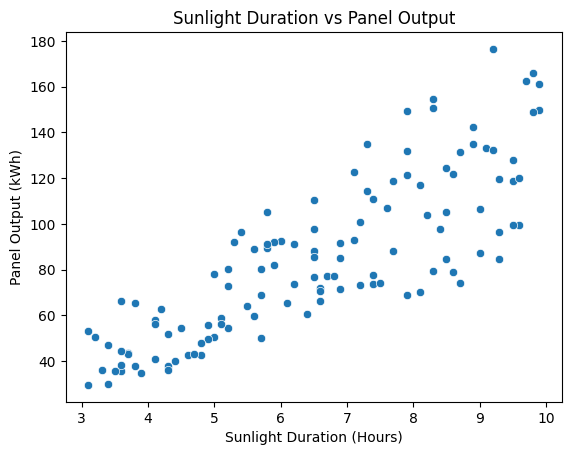

In [ ]:
sns.scatterplot(
    data=df,
    x='sunlight_duration_hours',
    y='panel_output_kwh'
)

plt.title('Sunlight Duration vs Panel Output')
plt.xlabel('Sunlight Duration (Hours)')
plt.ylabel('Panel Output (kWh)')
plt.show()

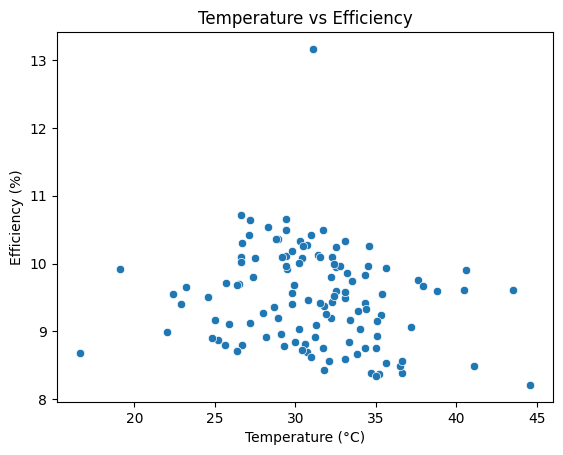

In [ ]:
sns.scatterplot(
    data=df,
    x='ambient_temperature_c',
    y='efficiency'
)

plt.title('Temperature vs Efficiency')
plt.xlabel('Temperature (°C)')
plt.ylabel('Efficiency (%)')
plt.show()

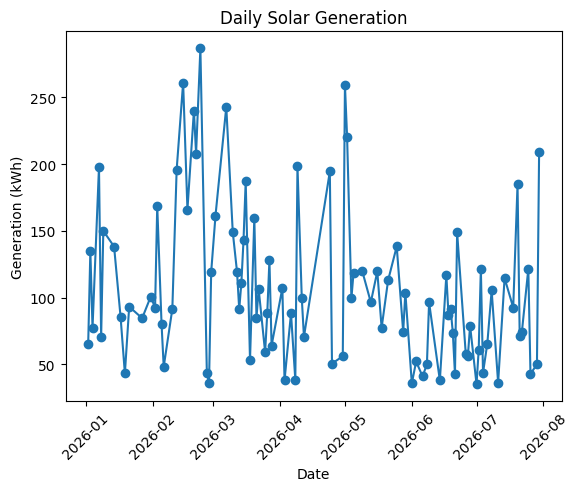

In [ ]:
daily = df.groupby('date')['panel_output_kwh'].sum()

plt.plot(daily.index, daily.values, marker='o')

plt.title('Daily Solar Generation')
plt.xlabel('Date')
plt.ylabel('Generation (kWh)')
plt.xticks(rotation=45)

plt.show()

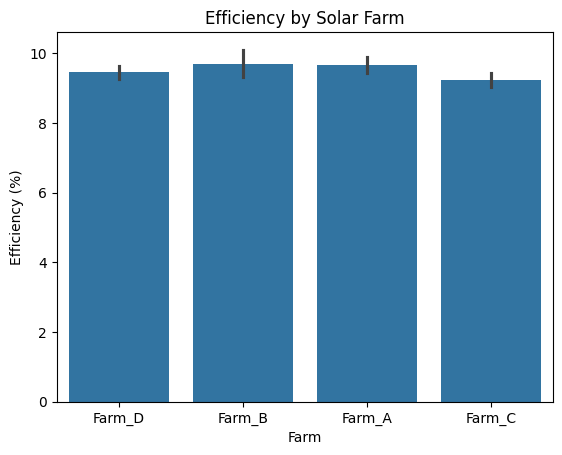

In [ ]:
sns.barplot(
    data=df,
    x='farm',
    y='efficiency'
)

plt.title('Efficiency by Solar Farm')
plt.xlabel('Farm')
plt.ylabel('Efficiency (%)')
plt.show()

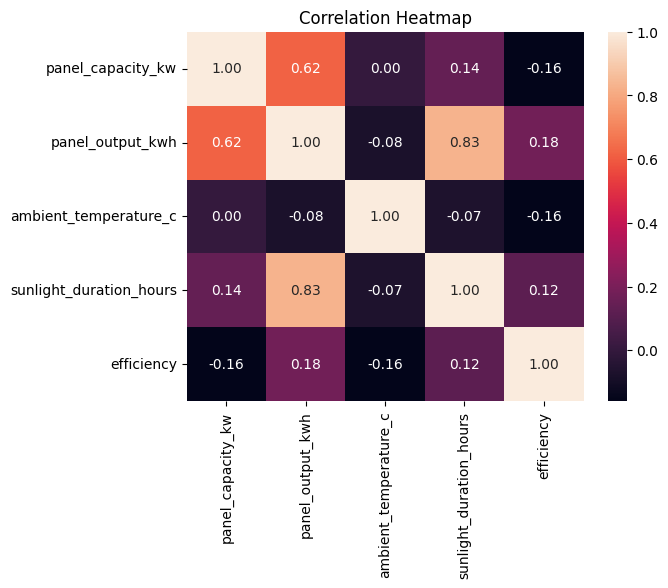

In [ ]:
corr = df[
    ['panel_capacity_kw',
     'panel_output_kwh',
     'ambient_temperature_c',
     'sunlight_duration_hours',
     'efficiency']
].corr()

sns.heatmap(corr, annot=True, fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print("========== FINDINGS ==========")

print("1. Sunlight duration affects panel output.")
print("2. Daily generation varies over time.")
print("3. Temperature can affect efficiency.")
print("4. Farm efficiency differs between locations.")
print("5. Low efficiency requires maintenance inspection.")

========== FINDINGS ==========
1. Sunlight duration affects panel output.
2. Daily generation varies over time.
3. Temperature can affect efficiency.
4. Farm efficiency differs between locations.
5. Low efficiency requires maintenance inspection.
